In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
#import pingouin as pg
import numpy as np

**Loading of data**


In [ ]:
# Replace with our file path
df = pd.read_csv("ai_grading_final.csv")

# Required columns:
required_columns = [
    "answer_key_id",
    "true_mistakes",
    "prompt_type",
    "ai_estimated_mistakes"
]
print(df["ai_estimated_mistakes"])
# Dependent variable: AI grading error
df["ai_error"] = df["ai_estimated_mistakes"] - df["true_mistakes"]
df["Absolute_error"] = abs(df["ai_estimated_mistakes"]-df["true_mistakes"])
df["true_mistakes"] = df["true_mistakes"].astype("category")
df["prompt_type"] = df["prompt_type"].astype("category")

0       14
1       14
2       14
3       10
4       14
        ..
1992     0
1993     0
1994     0
1995     0
1996     0
Name: ai_estimated_mistakes, Length: 1997, dtype: int64


**2-way Mixed ANOVA**

Assumptions: Homogeneity of variance, Independence of observations, Normally-distributed dependent variable 

In [4]:
mixed_anova = pg.mixed_anova(
    data=df,
    dv="ai_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

pg.print_table(mixed_anova)

# 10. Q-Q plot of residual-like centered scores

df["cell_mean"] = df.groupby(
    ["true_mistakes", "prompt_type"],
    observed=False
)["ai_error"].transform("mean")

df["anova_residual"] = df["ai_error"] - df["cell_mean"]

plt.figure(figsize=(7, 6))
stats.probplot(df["anova_residual"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Mixed ANOVA Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals vs condition means
#How far is this specific observation from the average result in the same condition? 
# One specific combination of true error level and prompt type.
#Condition means is the average value for each experimental condition.

plt.figure(figsize=(7, 5))
plt.scatter(df["cell_mean"], df["anova_residual"], alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Condition Means")
plt.xlabel("Condition mean")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot mean AI error by true mistakes and prompt

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("ai_error", "mean"),
        sd_ai_error=("ai_error", "std"),
        n=("ai_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )

plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'pg' is not defined

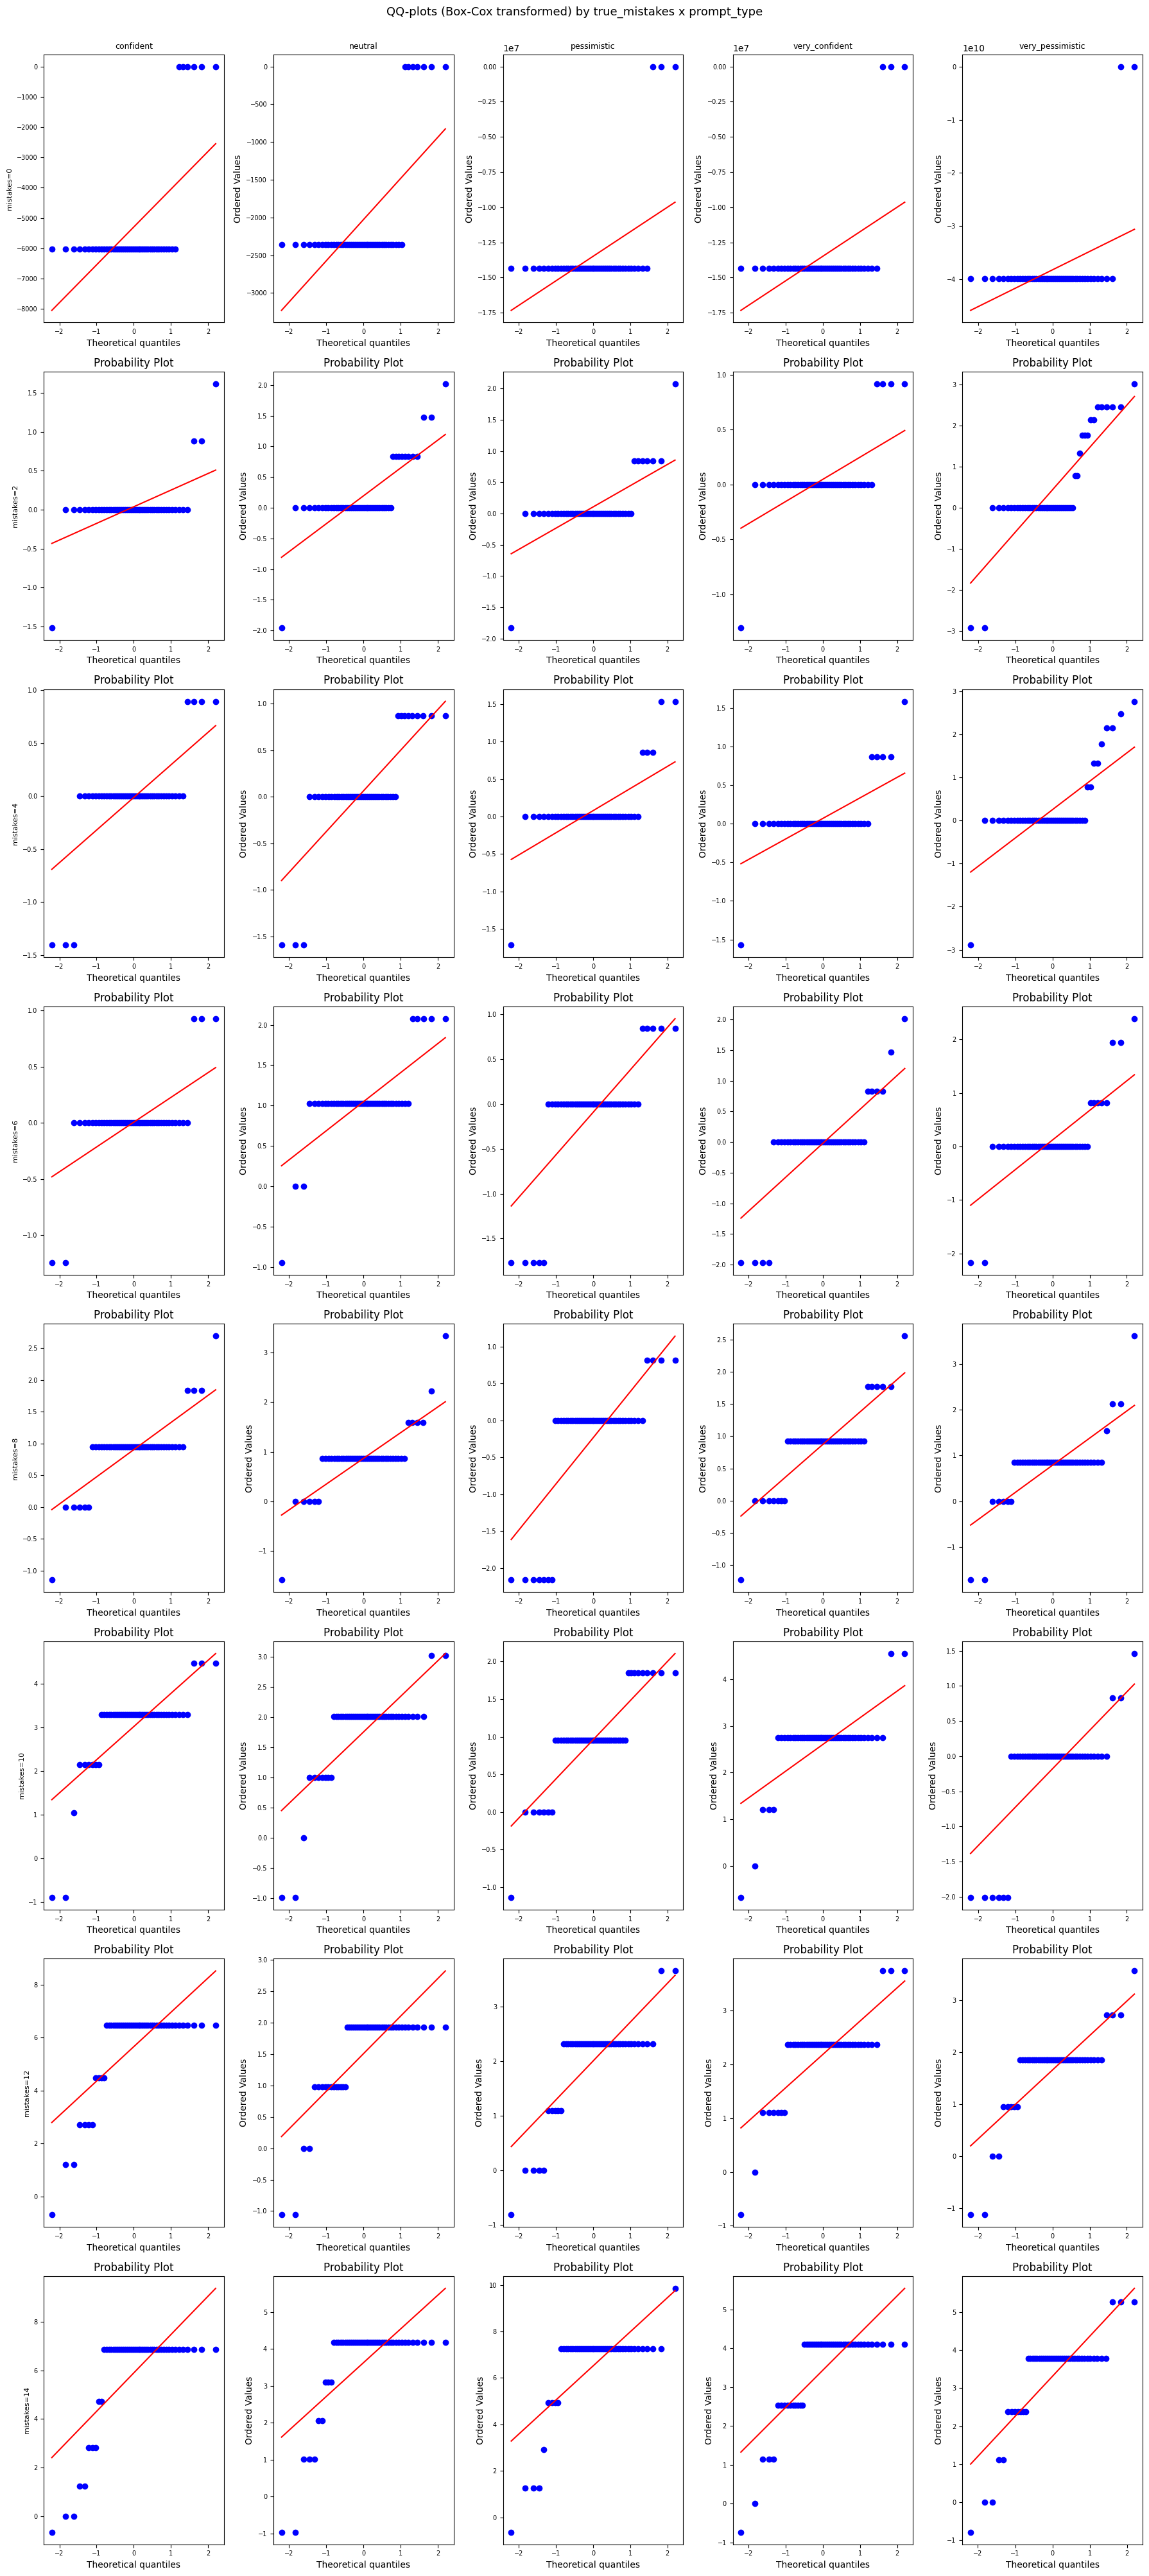

Sample of Box-Cox parameters:
(0, 'confident') {'lambda': np.float64(-0.5920417407160963), 'shift': np.float64(1e-06)}
(0, 'neutral') {'lambda': np.float64(-0.5139884957254528), 'shift': np.float64(1e-06)}
(0, 'pessimistic') {'lambda': np.float64(-1.2063722871038725), 'shift': np.float64(1e-06)}
(0, 'very_confident') {'lambda': np.float64(-1.2063722871038725), 'shift': np.float64(1e-06)}
(0, 'very_pessimistic') {'lambda': np.float64(-1.809560235155417), 'shift': np.float64(1e-06)}


In [13]:
# qq plot matrix (with optional Box-Cox)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

matrix = df.groupby(["true_mistakes", "prompt_type"])["ai_error"].apply(np.array).unstack("prompt_type")

types = ["confident", "neutral", "pessimistic", "very_confident", "very_pessimistic"]
rows = matrix.index.tolist()  # expected 16 true_mistakes levels


def boxcox_residuals(x, eps=1e-6):
    x = np.asarray(x).ravel().astype(float)

    # Box-Cox requires strictly positive values; shift each vector if needed.
    shift = 1.0
    min_x = np.min(x)
    if min_x <= 0:
        shift = -min_x + eps

    x_pos = x + shift

    # Box-Cox also needs non-constant data.
    if np.allclose(x_pos, x_pos[0]):
        return None, np.nan, shift

    x_bc, lam = stats.boxcox(x_pos)
    return x_bc, lam, shift


fig, axes = plt.subplots(len(rows), len(types), figsize=(18, 40), squeeze=False)
lambda_table = {}

for r, tm in enumerate(rows):
    for c, prompt in enumerate(types):
        ax = axes[r, c]

        if prompt not in matrix.columns:
            ax.set_visible(False)
            continue

        res_raw = matrix.loc[tm, prompt]
        if not isinstance(res_raw, (np.ndarray, list, tuple)):
            ax.set_visible(False)
            continue

        res = np.asarray(res_raw).ravel()
        if res.size < 3:
            ax.set_visible(False)
            continue

        res_bc, lam, shift = boxcox_residuals(res)
        if res_bc is None:
            ax.set_visible(False)
            continue

        stats.probplot(res_bc, dist="norm", plot=ax)
        lambda_table[(tm, prompt)] = {"lambda": lam, "shift": shift}

        if r == 0:
            ax.set_title(prompt, fontsize=9)
        if c == 0:
            ax.set_ylabel(f"mistakes={tm}", fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle("QQ-plots (Box-Cox transformed) by true_mistakes x prompt_type", y=1.002, fontsize=13)
plt.tight_layout()
plt.show()

print("Sample of Box-Cox parameters:")
for k, v in list(lambda_table.items())[:5]:
    print(k, v)

In [14]:
# Post-hoc tests between prompts
# Since prompt_type is a repeated-measures factor, comparisons between prompts should be paired t-tests with holm-correction.

posthoc_prompts = pg.pairwise_tests(
    data=df,
    dv="ai_error",
    within="prompt_type",
    subject="answer_key_id",
    parametric=True,
    padjust="holm",
    effsize="hedges"
)

print(posthoc_prompts)


      Contrast                          A                        B  Paired  \
0  prompt_type  prompt_1_very_pessimistic     prompt_2_pessimistic    True   
1  prompt_type  prompt_1_very_pessimistic         prompt_3_neutral    True   
2  prompt_type  prompt_1_very_pessimistic       prompt_4_confident    True   
3  prompt_type  prompt_1_very_pessimistic  prompt_5_very_confident    True   
4  prompt_type       prompt_2_pessimistic         prompt_3_neutral    True   
5  prompt_type       prompt_2_pessimistic       prompt_4_confident    True   
6  prompt_type       prompt_2_pessimistic  prompt_5_very_confident    True   
7  prompt_type           prompt_3_neutral       prompt_4_confident    True   
8  prompt_type           prompt_3_neutral  prompt_5_very_confident    True   
9  prompt_type         prompt_4_confident  prompt_5_very_confident    True   

   Parametric          T    dof alternative         p_unc        p_corr  \
0        True   7.117956  479.0   two-sided  4.027446e-12  1.61097

**ABSOLUTE ERROR VERSION**

In [ ]:
import pingouin as pg

mixed_anova = pg.mixed_anova(
    data=df,
    dv="Absolute_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

pg.print_table(mixed_anova)

# 10. Q-Q plot of residual-like centered scores

df["cell_mean"] = df.groupby(
    ["true_mistakes", "prompt_type"],
    observed=False
)["Absolute_error"].transform("mean")

df["anova_residual"] = df["Absolute_error"] - df["cell_mean"]

plt.figure(figsize=(7, 6))
stats.probplot(df["anova_residual"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Mixed ANOVA Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals vs condition means

plt.figure(figsize=(7, 5))
plt.scatter(df["cell_mean"], df["anova_residual"], alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Condition Means")
plt.xlabel("Condition mean")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot mean AI error by true mistakes and prompt

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("Absolute_error", "mean"),
        sd_ai_error=("Absolute_error", "std"),
        n=("Absolute_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )

plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Post-hoc tests between prompts
# Since prompt_type is a repeated-measures factor, comparisons between prompts should be paired t-tests with holm-correction.

posthoc_prompts = pg.pairwise_tests(
    data=df,
    dv="Absolute_error",
    within="prompt_type",
    subject="answer_key_id",
    parametric=True,
    padjust="holm",
    effsize="hedges"
)

print(posthoc_prompts)
